In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pickle
import bs4 as bs
import urllib.request
import nltk
import spacy

pos:https://spacy.io/api/annotation#pos-tagging

pos-pt: https://www.sketchengine.eu/portuguese-freeling-part-of-speech-tagset/

In [5]:
pln = spacy.load("pt_core_news_sm")
pln

In [6]:
documento = pln("estou aprendendo processamento de linguagem natural")

In [7]:
for token in documento:
    print(token.text,token.pos_)

estou AUX
aprendendo VERB
processamento NOUN
de ADP
linguagem NOUN
natural ADJ


In [8]:
for token in documento:
    print(token.text,token.lemma_)

estou estar
aprendendo aprender
processamento processamento
de de
linguagem linguagem
natural natural


In [9]:
nltk.download("rslp")

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\teamd\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping stemmers\rslp.zip.


True

In [10]:
stemmer = nltk.stem.RSLPStemmer()
stemmer.stem("aprender")

'aprend'

In [11]:
for token in documento:
    print(token.text,token.lemma_,stemmer.stem(token.text))

estou estar est
aprendendo aprender aprend
processamento processamento process
de de de
linguagem linguagem lingu
natural natural natur


OUTRA AULA:CARREGAMENTO DE DADOS

In [12]:
dados = urllib.request.urlopen("https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial")

In [13]:
dados = dados.read()
dados

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-toc-available" lang="pt" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Intelig\xc3\xaancia artificial \xe2\x80\x93 Wikip\xc3\xa9dia, a enciclop\xc3\xa9dia livre</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-me

In [17]:
dados_html = bs.BeautifulSoup(dados)
dados_html

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-toc-available" dir="ltr" lang="pt">
<head>
<meta charset="utf-8"/>
<title>Inteligência artificial – Wikipédia, a enciclopédia livre</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-lim

In [18]:
paragrafos = dados_html.find_all("p")

In [19]:
len(paragrafos)

64

In [21]:
paragrafos[0].text

'A inteligência artificial (de sigla: IA; do inglês: artificial intelligence, de sigla: AI) é um campo de estudo multidisciplinar que abrange varias áreas do conhecimento.[1][2] É também um conjunto de novas tecnologias que permitem aos aparelhos smart executarem várias funções avançadas de modo quase autônomo,[2][3] representando um marco histórico na computação moderna.[3] Embora seu desenvolvimento tenha avançado mais na ciência da computação, sua abordagem interdisciplinar envolve contribuições de diversas disciplina.\n'

In [22]:
conteudo = ""

for p in paragrafos:
    conteudo += p.text

In [23]:
conteudo

'A inteligência artificial (de sigla: IA; do inglês: artificial intelligence, de sigla: AI) é um campo de estudo multidisciplinar que abrange varias áreas do conhecimento.[1][2] É também um conjunto de novas tecnologias que permitem aos aparelhos smart executarem várias funções avançadas de modo quase autônomo,[2][3] representando um marco histórico na computação moderna.[3] Embora seu desenvolvimento tenha avançado mais na ciência da computação, sua abordagem interdisciplinar envolve contribuições de diversas disciplina.\nAlgumas das principais áreas relacionadas à IA incluem:\nÉ difícil definir especificamente a Inteligência Artificial, mas ao longo do tempo seguiu essas quatro linhas de pensamento:[1]\nÉ um conceito amplo e que recebe tantas definições quanto significados diferentes à palavra inteligência.[4] É possível considerar algumas características básicas desses sistemas, como a capacidade de raciocínio (aplicar regras lógicas a um conjunto de dados disponíveis para chegar a 

In [24]:
conteudo = conteudo.lower()

In [25]:
string = "turing"
token_pesquisa = pln(string)

In [26]:
pln.vocab

In [29]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(pln.vocab)
matcher.add("SEARCH",None,token_pesquisa)


In [30]:
doc = pln(conteudo)
matches = matcher(doc)
matches

[(8661325627334373315, 3463, 3464),
 (8661325627334373315, 3473, 3474),
 (8661325627334373315, 3629, 3630),
 (8661325627334373315, 3634, 3635),
 (8661325627334373315, 3640, 3641),
 (8661325627334373315, 3703, 3704),
 (8661325627334373315, 4356, 4357),
 (8661325627334373315, 5573, 5574),
 (8661325627334373315, 5708, 5709),
 (8661325627334373315, 5803, 5804),
 (8661325627334373315, 5920, 5921)]

In [32]:
doc[3463:3464],doc[3463-5:3464+5]

(turing, uma contribuição prática de alan turing foi o que se chamou)

In [40]:
from IPython.core.display import HTML
numero_palavras = 50
doc = pln(conteudo)
matches = matcher(doc)

display(HTML(f"<h1>{string.upper()}</h1>"))
display(HTML(f"""<p><strong>Resultados escontrados: </strong>{len(matches)} </p> """))
for i in matches:
    inicio = i[1]- numero_palavras
    if inicio<0:
        inicio = 0
    texto = str(doc[inicio:i[2]+ numero_palavras]).replace(string,f"<mark>{string}</mark>")
    texto += "<br/><br/>"
display(HTML(f""" ...{texto}..."""))

In [42]:
for entidade in doc.ents:
    print(entidade.text,entidade.label_)

pensamento:[1 MISC
segunda guerra mundial MISC
alan PER
herbert simon PER
allen newell PER
john mccarthy PER
warren mcculloch PER
walter pitts PER
marvin minsky PER
frankenstein MISC
aristóteles PER
alexandre PER
herbert simon PER
john mccarthy PER
newell PER
“ PER
” MISC
humano.[14 MISC
brasil LOC
allen newell PER
herbert simon PER
marvin minsky PER
mit ORG
lab MISC
defense advanced research MISC
estados unidos LOC
fifth generation MISC
” MISC
japão LOC
prolog MISC
google ORG
wikipédia MISC
john mccarthy PER
racionalmente".[18][25 MISC
andreas kaplan PER
michael haenlein PER
john mccarthy PER
román LOC
john haugeland PER
w. grey walter PER
johns hopkins PER
universidade de princeton ORG
ratio club LOC
inglaterra LOC
david rumelhart PER
isaac asimov PER
steven spielberg PER
alan turing PER
turing PER
turing PER
turing PER
tommy flowers PER
joseph weizenbaum PER
mit ORG
internet computer entity MISC
internet MISC
java MISC
intelligence markup language PER
alicebots LOC
programáveis.[35]

In [43]:
from spacy import displacy
displacy.render(doc,style="ent",jupyter=True)

nuvem de palavras

In [51]:
from spacy.lang.pt.stop_words import STOP_WORDS
print(STOP_WORDS)

{'final', 'parte', 'sétima', 'possível', 'uma', 'estou', 'fará', 'inclusive', 'querem', 'cujo', 'dezanove', 'nossa', 'tipo', 'bastante', 'próprio', 'ambas', 'foi', 'da', 'for', 'pelas', 'toda', 'estivemos', 'área', 'sexta', 'ligado', 'quarta', 'próximo', 'bom', 'sabe', 'naquele', 'mal', 'lugar', 'foram', 'boa', 'bem', 'nuns', 'somente', 'e', 'nenhuma', 'ali', 'aos', 'tendes', 'esta', 'inicio', 'breve', 'des', 'desta', 'tempo', 'vários', 'dezassete', 'meses', 'vezes', 'posso', 'nós', 'algumas', 'sétimo', 'treze', 'aqueles', 'quando', 'a', 'mil', 'porquê', 'fora', 'outras', 'isso', 'tivemos', 'dez', 'o', 'números', 'estas', 'ele', 'era', 'fazeis', 'irá', 'portanto', 'esses', 'tudo', 'após', 'neste', 'suas', 'dessa', 'cá', 'estar', 'apontar', 'essa', 'pouca', 'entre', 'umas', 'vai', 'vem', 'zero', 'sob', 'dar', 'isto', 'obrigada', 'tens', 'uns', 'muito', 'sua', 'tivestes', 'catorze', 'dois', 'então', 'estado', 'onze', 'quieta', 'vinte', 'maiorias', 'qual', 'parece', 'és', 'numa', 'certame

In [53]:
doc = pln(conteudo)
lista_token = []
for token in doc:
    lista_token.append(token.text)

sem_stop = []
for palavra in lista_token:
    if pln.vocab[palavra].is_stop == False:
        sem_stop.append(palavra)

In [48]:
from matplotlib.colors import ListedColormap
color_map = ListedColormap(["orange","green","red","pink"])

In [49]:
from wordcloud import WordCloud
cloud = WordCloud(background_color="white",max_words=100,colormap=color_map)

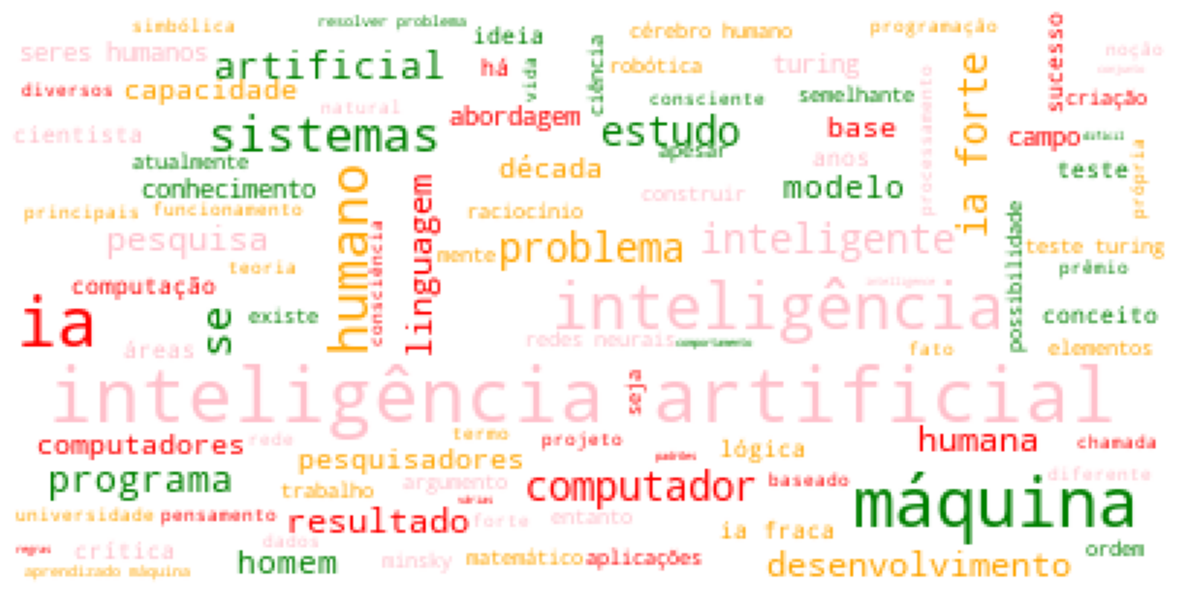

In [56]:
cloud = cloud.generate(" ".join(sem_stop))
plt.figure(figsize=(15,15))
plt.imshow(cloud)
plt.axis("off")
plt.show()